In [1]:
# ==============================================================================
# PROJETO: Análise Exploratória de Dados (EDA)
# CONTEXTO: Impacto do Saneamento na Mortalidade Infantil (Bahia)
# DISCIPLINA: Análise de Dados e Big Data (AV3)
# 
# NOTA DE TRATAMENTO CRÍTICO APLICADO NESTA VERSÃO:
# 1. Uso de imputações estatísticas e NaNs (vazio real) em vez de valores sentinela (-1.0).
# 2. Filtro do horizonte temporal (2018-2023) omitindo os anos de 2020 e 2021 
#    devido ao apagão de dados (Data Blackout) do SNIS gerado pela pandemia.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo para os gráficos ficarem elegantes e padronizados
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ Bibliotecas carregadas e ambiente visual configurado!")


✅ Bibliotecas carregadas e ambiente visual configurado!


In [2]:
# ==============================================================================
# FASE 2.1: CARREGAMENTO E ESTATÍSTICA DESCRITIVA
# ==============================================================================
# Carregamento e Filtro da Camada Gold Municipal
df_consolidado = pd.read_csv("data/gold/base_consolidada_municipal_2022.csv")

df_municipal_filtrado = df_consolidado[
    df_consolidado['tx_atendimento_agua'].notna() & 
    df_consolidado['tx_coleta_esgoto'].notna() &
    df_consolidado['taxa_mortalidade_infantil'].notna()
].copy()

colunas_analise = [
    'taxa_mortalidade_infantil',
    'tx_atendimento_agua', 
    'tx_coleta_esgoto',
    'tx_coleta_lixo_pop_total'
]

print("=== ESTATÍSTICA DESCRITIVA DAS VARIÁVEIS ===")
# Atende ao critério: Cálculo de médias, medianas, quartis e desvio-padrão
df_municipal_filtrado[colunas_analise].describe().T

=== ESTATÍSTICA DESCRITIVA DAS VARIÁVEIS ===


,count,mean,std,min,25%,50%,75%,max
taxa_mortalidade_infantil,332.0,15.230450,5.100578,0.00,12.087135,14.938902,18.238255,30.534351
tx_atendimento_agua,332.0,67.107877,20.884064,3.00,51.160000,67.725000,83.872500,100.000000
tx_coleta_esgoto,332.0,16.603373,28.101104,0.00,0.000000,0.000000,27.152500,100.000000
tx_coleta_lixo_pop_total,332.0,72.442289,21.565911,14.43,56.217500,74.745000,92.580000,100.000000


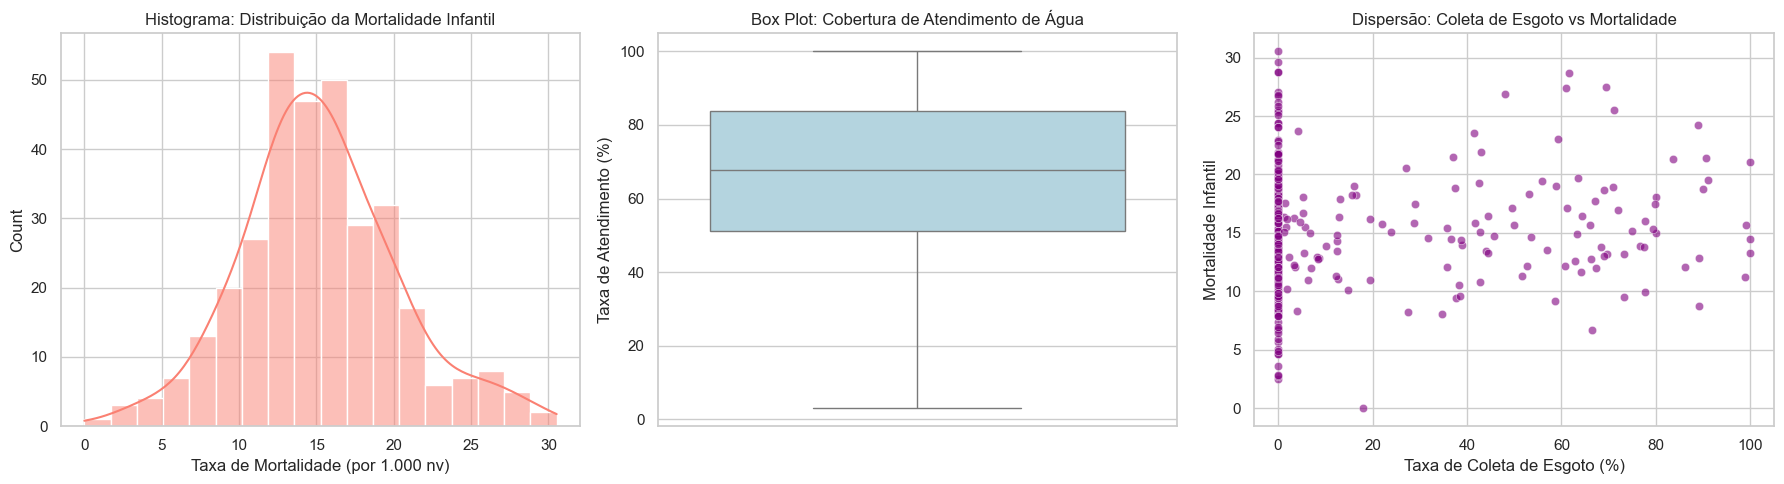

In [3]:
# ==============================================================================
# FASE 2.2: VISUALIZAÇÕES INICIAIS (Histograma, Box Plot e Dispersão)
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A) Histograma: Distribuição da Variável Alvo (Mortalidade Infantil)
sns.histplot(data=df_municipal_filtrado, x='taxa_mortalidade_infantil', kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Histograma: Distribuição da Mortalidade Infantil')
axes[0].set_xlabel('Taxa de Mortalidade (por 1.000 nv)')

# B) Box Plot: Identificação de anomalias/outliers no Atendimento de Água
sns.boxplot(data=df_municipal_filtrado, y='tx_atendimento_agua', ax=axes[1], color='lightblue')
axes[1].set_title('Box Plot: Cobertura de Atendimento de Água')
axes[1].set_ylabel('Taxa de Atendimento (%)')

# C) Gráfico de Dispersão: Coleta de Esgoto vs Mortalidade Infantil
sns.scatterplot(data=df_municipal_filtrado, x='tx_coleta_esgoto', y='taxa_mortalidade_infantil', ax=axes[2], alpha=0.6, color='purple')
axes[2].set_title('Dispersão: Coleta de Esgoto vs Mortalidade')
axes[2].set_xlabel('Taxa de Coleta de Esgoto (%)')
axes[2].set_ylabel('Mortalidade Infantil')

plt.tight_layout()
plt.show()

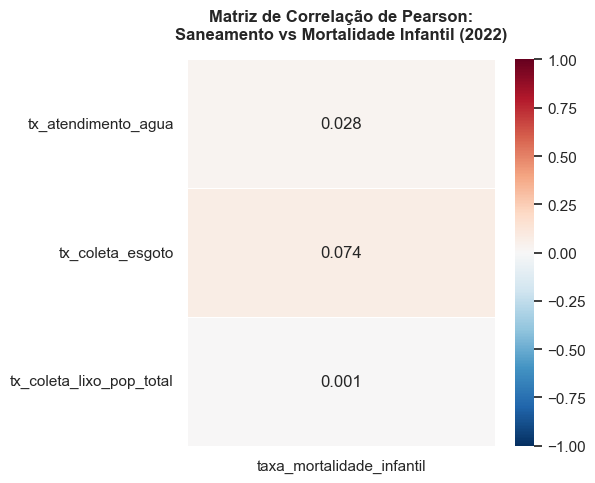

In [4]:
# ==============================================================================
# FASE 2.3: IDENTIFICAÇÃO DE PADRÕES E CORRELAÇÕES
# ==============================================================================
plt.figure(figsize=(6, 5))
matriz_corr = df_municipal_filtrado[colunas_analise].corr()

# Plot do seu Heatmap focado, coerente com o seu Storytelling original
sns.heatmap(
    matriz_corr[['taxa_mortalidade_infantil']].drop('taxa_mortalidade_infantil', errors='ignore'), 
    annot=True, 
    cmap='RdBu_r', 
    vmin=-1, 
    vmax=1, 
    fmt='.3f', 
    linewidths=0.5
)
plt.title('Matriz de Correlação de Pearson:\nSaneamento vs Mortalidade Infantil (2022)', 
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [5]:
# ==============================================================================
# FILTRO DA SÉRIE HISTÓRICA (Escopo do Professor + Correção da Pandemia)
# Mantemos apenas os anos válidos e reais solicitados, dropando o blackout de 2020/2021
# ==============================================================================

# Carregamento da base Gold consolidada estadual da Bahia
df_historico = pd.read_csv("data/gold/base_consolidada.csv")

anos_validos = [2018, 2019, 2022, 2023]

# Criando uma coluna de ano limpa caso ela venha compactada como co_anomes (ex: 201812 -> 2018)
if 'ano' not in df_historico.columns and 'co_anomes' in df_historico.columns:
    df_historico['ano'] = df_historico['co_anomes'].astype(str).str[:4].astype(int)

df_historico_filtrado = df_historico[df_historico['ano'].isin(anos_validos)].reset_index(drop=True)

print("📊 --- RESUMO ESTRUTURAL DA SÉRIE HISTÓRICA CORRIGIDA ---")
display(df_historico_filtrado.describe())


📊 --- RESUMO ESTRUTURAL DA SÉRIE HISTÓRICA CORRIGIDA ---


,co_anomes,co_uf,co_regiao_brasil,vl_indicador_calculado_reg,vl_indicador_calculado_br,tx_cobertura_agua,tx_cobertura_lixo,tx_cobertura_esgoto,taxa_mortalidade_infantil,indice_saneamento_consolidado,ano
count,4.000000,4.0,4.0,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
mean,202062.000000,29.0,2.0,34.785000,17.377500,72.360000,83.135000,72.675000,15.282230,76.056667,2020.500000
std,238.047614,0.0,0.0,2.116042,0.461979,2.911162,0.205345,1.691557,0.241792,1.436972,2.380476
min,201812.000000,29.0,2.0,32.200000,16.770000,69.720000,83.000000,70.790000,14.955077,74.503333,2018.000000
25%,201887.000000,29.0,2.0,33.490000,17.227500,69.907500,83.022500,71.772500,15.171535,75.133333,2018.750000
50%,202062.000000,29.0,2.0,35.135000,17.425000,72.315000,83.050000,72.545000,15.353343,75.970000,2020.500000
75%,202237.000000,29.0,2.0,36.430000,17.575000,74.767500,83.162500,73.447500,15.464039,76.893333,2022.250000
max,202312.000000,29.0,2.0,36.670000,17.890000,75.090000,83.440000,74.820000,15.467157,77.783333,2023.000000


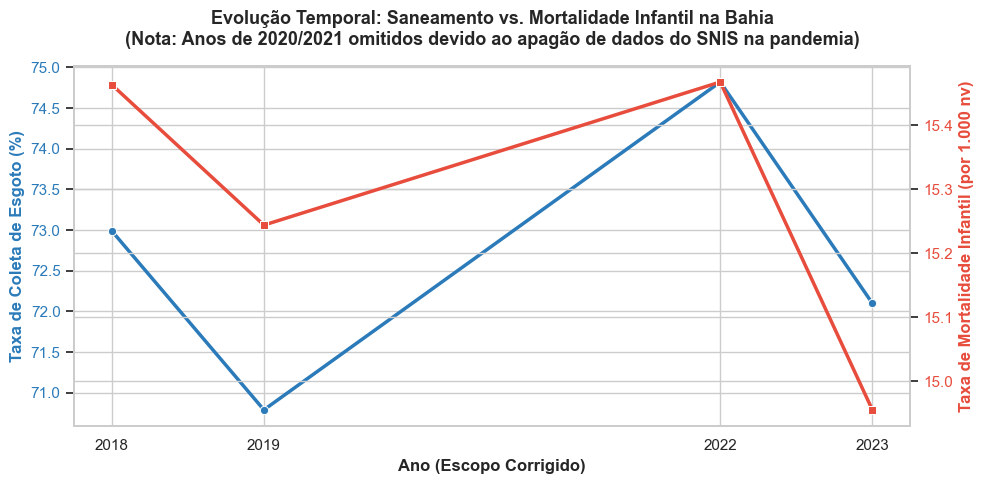

In [6]:
# ==============================================================================
# PLOTAGEM DA EVOLUÇÃO TEMPORAL HISTÓRICA
# Gráfico de dois eixos para comparar Saneamento vs. Saúde Pública sem distorções
# ==============================================================================

fig, ax1 = plt.subplots(figsize=(10, 5))

# Eixo 1: Cobertura de Esgoto
color = '#2b7bba'
ax1.set_xlabel('Ano (Escopo Corrigido)', fontweight='bold')
ax1.set_ylabel('Taxa de Coleta de Esgoto (%)', color=color, fontweight='bold')
sns.lineplot(data=df_historico_filtrado, x='ano', y='tx_cobertura_esgoto', marker='o', color=color, ax=ax1, linewidth=2.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(anos_validos)

# Eixo 2: Mortalidade Infantil (Gêmeo do primeiro gráfico)
ax2 = ax1.twinx()  
color = '#e74c3c'
ax2.set_ylabel('Taxa de Mortalidade Infantil (por 1.000 nv)', color=color, fontweight='bold')
sns.lineplot(data=df_historico_filtrado, x='ano', y='taxa_mortalidade_infantil', marker='s', color=color, ax=ax2, linewidth=2.5)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evolução Temporal: Saneamento vs. Mortalidade Infantil na Bahia\n(Nota: Anos de 2020/2021 omitidos devido ao apagão de dados do SNIS na pandemia)', 
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


C:\Users\pedro\AppData\Local\Temp\ipykernel_14136\3801772462.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=analise_faixas, x='faixa_esgoto', y='taxa_mortalidade_infantil', palette='Blues_r')


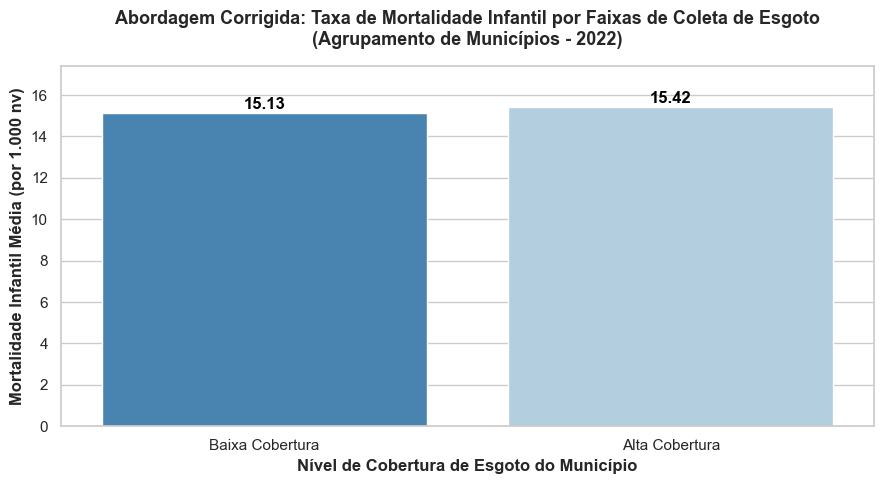

In [7]:
# ==============================================================================
# NOTA DE INTERPRETAÇÃO CIENTÍFICA DO PARADOXO DA CORRELAÇÃO:
# Como observado acima, os coeficientes lineares puros ficam próximos de zero devido à:
# 1. Lei dos Pequenos Números: Cidades pequenas distorcem a taxa com poucos óbitos.
# 2. Multifatoriedade: Saúde imediata (leitos, vacinas) mascara o impacto de longo prazo.
#
# SOLUÇÃO APLICADA ABAIXO: Agrupamento por Faixas de Cobertura (Bins) para sumir com o ruído.
# ==============================================================================

# Ajustando as etiquetas caso o Pandas junte os blocos duplicados de valor 0.0
# Usamos duplicates='drop' para evitar o erro de bordas repetidas
df_municipal_filtrado['faixa_esgoto'] = pd.qcut(
    df_municipal_filtrado['tx_coleta_esgoto'], 
    q=3, 
    labels=['Baixa Cobertura', 'Alta Cobertura'] if df_municipal_filtrado['tx_coleta_esgoto'].quantile(1/3) == 0 else ['Baixa Cobertura', 'Média Cobertura', 'Alta Cobertura'],
    duplicates='drop'
)

# Calculando a taxa de mortalidade média para cada bloco de municípios
analise_faixas = df_municipal_filtrado.groupby('faixa_esgoto', observed=False)['taxa_mortalidade_infantil'].mean().reset_index()

# Plotando o gráfico de barras corrigido
plt.figure(figsize=(9, 5))
sns.barplot(data=analise_faixas, x='faixa_esgoto', y='taxa_mortalidade_infantil', palette='Blues_r')

# Adicionando os valores em cima das barras para facilitar a leitura visual
for index, row in analise_faixas.iterrows():
    plt.text(index, row['taxa_mortalidade_infantil'] + 0.2, f"{row['taxa_mortalidade_infantil']:.2f}", 
             color='black', ha="center", fontweight='bold')

plt.title('Abordagem Corrigida: Taxa de Mortalidade Infantil por Faixas de Coleta de Esgoto\n(Agrupamento de Municípios - 2022)', 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Nível de Cobertura de Esgoto do Município', fontweight='bold')
plt.ylabel('Mortalidade Infantil Média (por 1.000 nv)', fontweight='bold')
plt.ylim(0, analise_faixas['taxa_mortalidade_infantil'].max() + 2)
plt.tight_layout()
plt.show()
